# YOLO Threshold Analysis Test
Adapted from https://oceancv.org/book/OceanCVLocalizing_YOLO.html

In [1]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

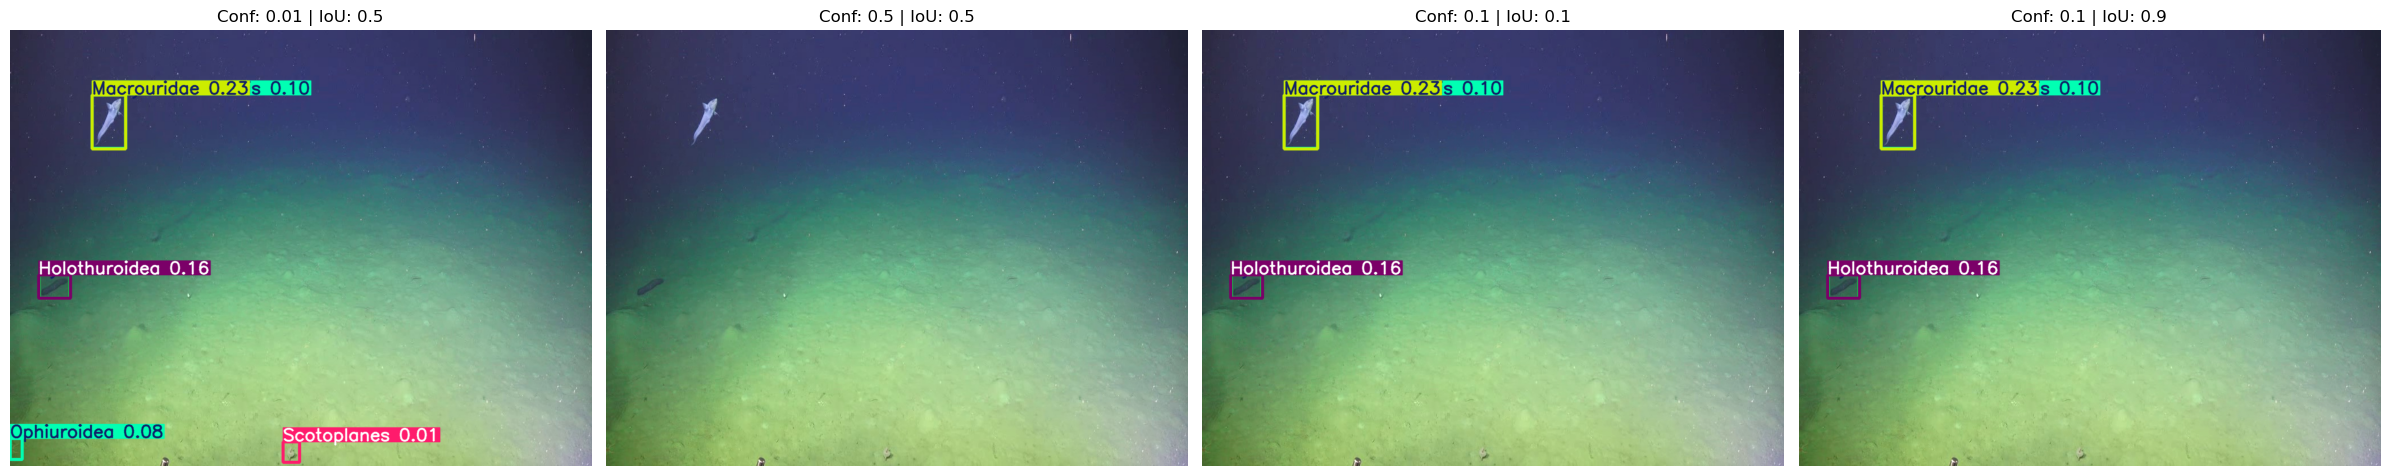

In [2]:
model = YOLO("./yolo-test/mbari_315k_yolov8.pt")
image_path = "yolo-test/frames/frame_65757.jpg"

threshold_settings = [(0.01, 0.5), (0.5, 0.5), (0.1, 0.1), (0.1, 0.9)]
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (conf, iou) in zip(axes, threshold_settings):
    results = model.predict(image_path, conf=conf, iou=iou, verbose=False)
    res_plotted = results[0].plot()
    ax.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Conf: {conf} | IoU: {iou}")
    ax.axis('off')

plt.tight_layout()
plt.show()